In [103]:
source("/rd1/user/lit/project/sORFs/sORFs.utils.R")
source("~/bin/lit_utils.R")
lib_text()
lib_plot()
setwd("/rd1/user/lit/project/sORFs/analysis/20250523_human_ms_run/")
output_path <- "./stat_output/S6_v2"
create_path(output_path)
fread_c("./stat_output/S1/sample_metadata_ordered.txt") -> sample_metadata
# 去掉PCP第4个重复
sample_metadata %>% filter(Replicate!=4)  %>% filter(Eyzyme!='Null') -> sample_metadata
psm_sep_all_path <- '/rd1/user/lit/project/sORFs/analysis/20250523_human_ms_run/stat_output/S6/psm_sep_all.txt'
fread_c(psm_sep_all_path) -> psm_sep_all
psm_sep_all %>% filter(PSM_type=="Unique") -> psm_sep_unique
# 去掉PCP第4个重复
psm_sep_unique %>% filter(!grepl("4_PCP",psm_sep_unique$Sample) & !grepl("less3K",psm_sep_unique$Sample)) -> psm_sep_unique
psm_sep_unique %>% distinct(Protein,Sample) -> all_sample_sep
all_sample_sep %>% merge(sample_metadata,by = "Sample") -> all_sample_sep_m_meta
all_sample_sep_m_meta %>% arrange(Enrichment,Eyzyme,Replicate) -> all_sample_sep_m_meta

# 饱和曲线

## 没有合并重复之前 【弃用】

In [11]:
##### Saturation Plot #####
set.seed(123)
# sample_order <- sample(sample_metadata$Sample)
sample_order <- sample_metadata %>% arrange(Enrichment,Eyzyme,Replicate) %>% .$Sample
# 1. 蛋白累积分析（带柱状图）
res_protein <- cumu_combo_plot(
  df = psm_sep_unique,
  sample_order = sample_order,
  target_col = "Protein",
  show_bar = TRUE
)
ggsave("protein_cumulative_combo.pdf", width = 10, height = 5)
ggsave(res_protein$version_sampleNum,filename=o("cumu_pro_sample_n.pdf"),height = 5,width = 18)
ggsave(res_protein$version_sampleName,filename=o("cumu_pro_sample_name.pdf"),height = 5,width = 18)

# 2. 肽段累积分析（带柱状图）
res_peptide <- cumu_combo_plot(
  df = psm_sep_unique,
  sample_order = sample_order,
  target_col = "Peptide",
  show_bar = TRUE
)
ggsave(res_peptide$version_sampleNum,filename=o("cumu_pep_sample_n.pdf"),height = 5,width = 18)
ggsave(res_peptide$version_sampleName,filename=o("cumu_pep_sample_name.pdf"),height = 5,width = 18)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


## 合并重复之后的饱和曲线

In [80]:
merge_replicate <- function(df){
    # 合并重复
    df$Sample_merge_replicate <- gsub("21pcw(_1|_2|_3)", "21pcw", df$Sample)
    df %>% mutate(Sample=NULL) %>% rename(Sample=Sample_merge_replicate) -> df_1
    return(df_1)
}
merge_replicate(psm_sep_unique) -> df

In [86]:
##### Saturation Plot #####
set.seed(123)
# sample_order <- sample(sample_metadata$Sample)
# sample_order <- sample_metadata %>% arrange(Enrichment,Eyzyme,Replicate) %>% .$Sample
sample_order <- merge_replicate(all_sample_sep_m_meta) %>% .$Sample %>% unique()
# 1. 蛋白累积分析（带柱状图）
res_protein <- cumu_combo_plot(
  df = df,
  sample_order = sample_order,
  target_col = "Protein",
  show_bar = TRUE
)
ggsave("protein_cumulative_combo.pdf", width = 10, height = 5)
ggsave(res_protein$version_sampleNum,filename=o("cumu_pro_sample_n.pdf"),height = 5,width = 18)
ggsave(res_protein$version_sampleName,filename=o("cumu_pro_sample_name.pdf"),height = 5,width = 18)

# 2. 肽段累积分析（带柱状图）
res_peptide <- cumu_combo_plot(
  df = df,
  sample_order = sample_order,
  target_col = "Peptide",
  show_bar = TRUE
)
ggsave(res_peptide$version_sampleNum,filename=o("cumu_pep_sample_n.pdf"),height = 5,width = 18)
ggsave(res_peptide$version_sampleName,filename=o("cumu_pep_sample_name.pdf"),height = 5,width = 18)

# 不同重复之间的overlap

In [53]:
all_sample_sep_m_meta %>% filter(grepl("^sp",Protein)) -> all_sample_sep_m_meta_cano
all_sample_sep_m_meta_cano -> df

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


[1] 0.7934813

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


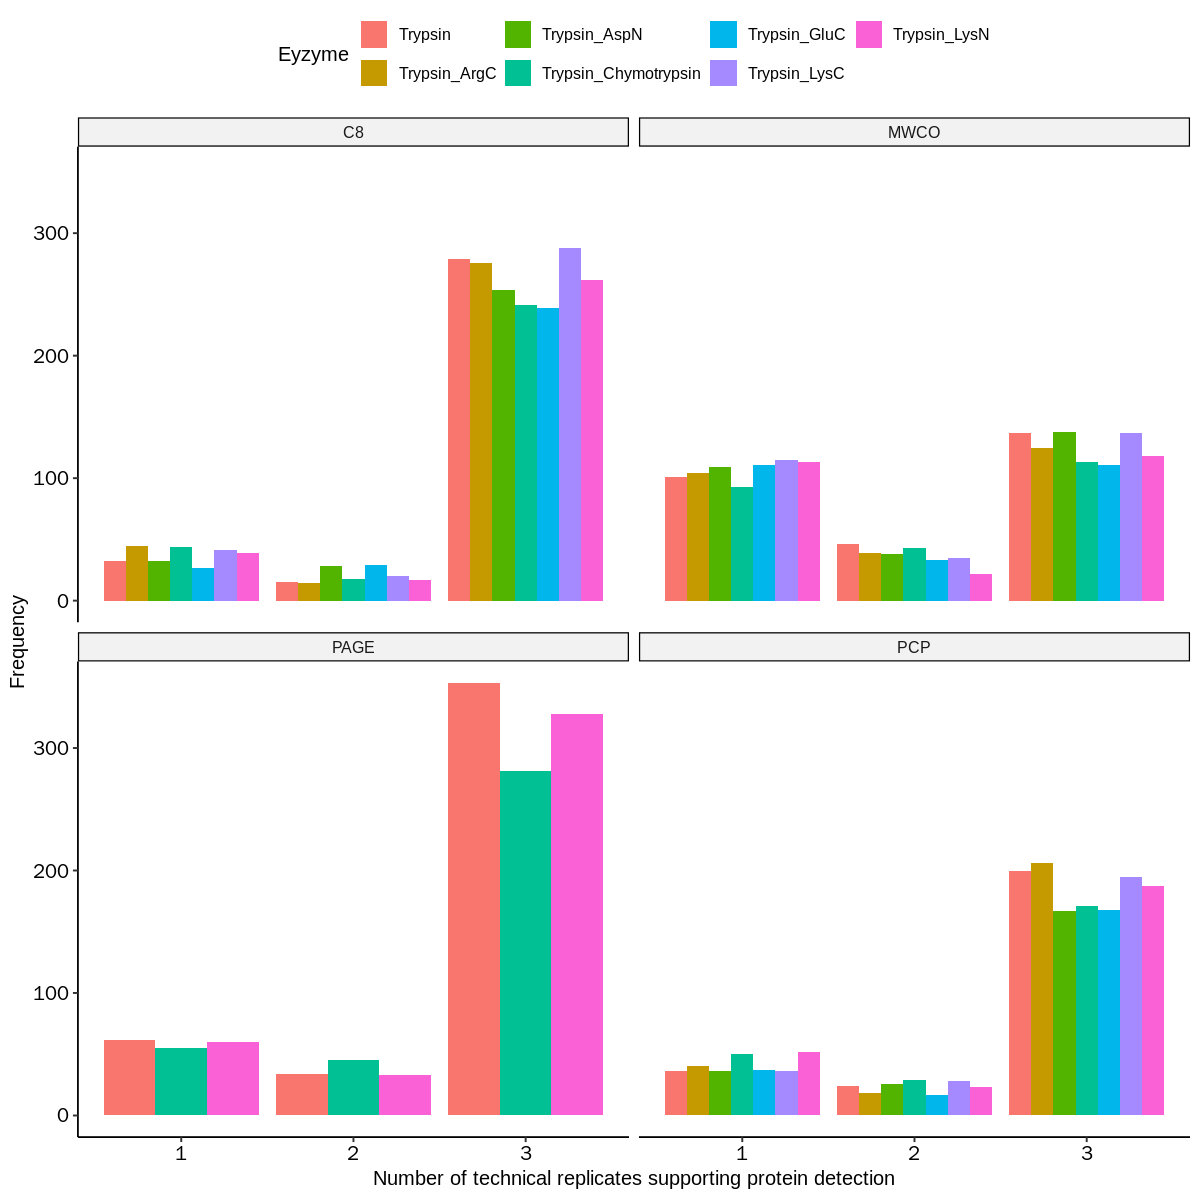

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


[1] 0.7228327

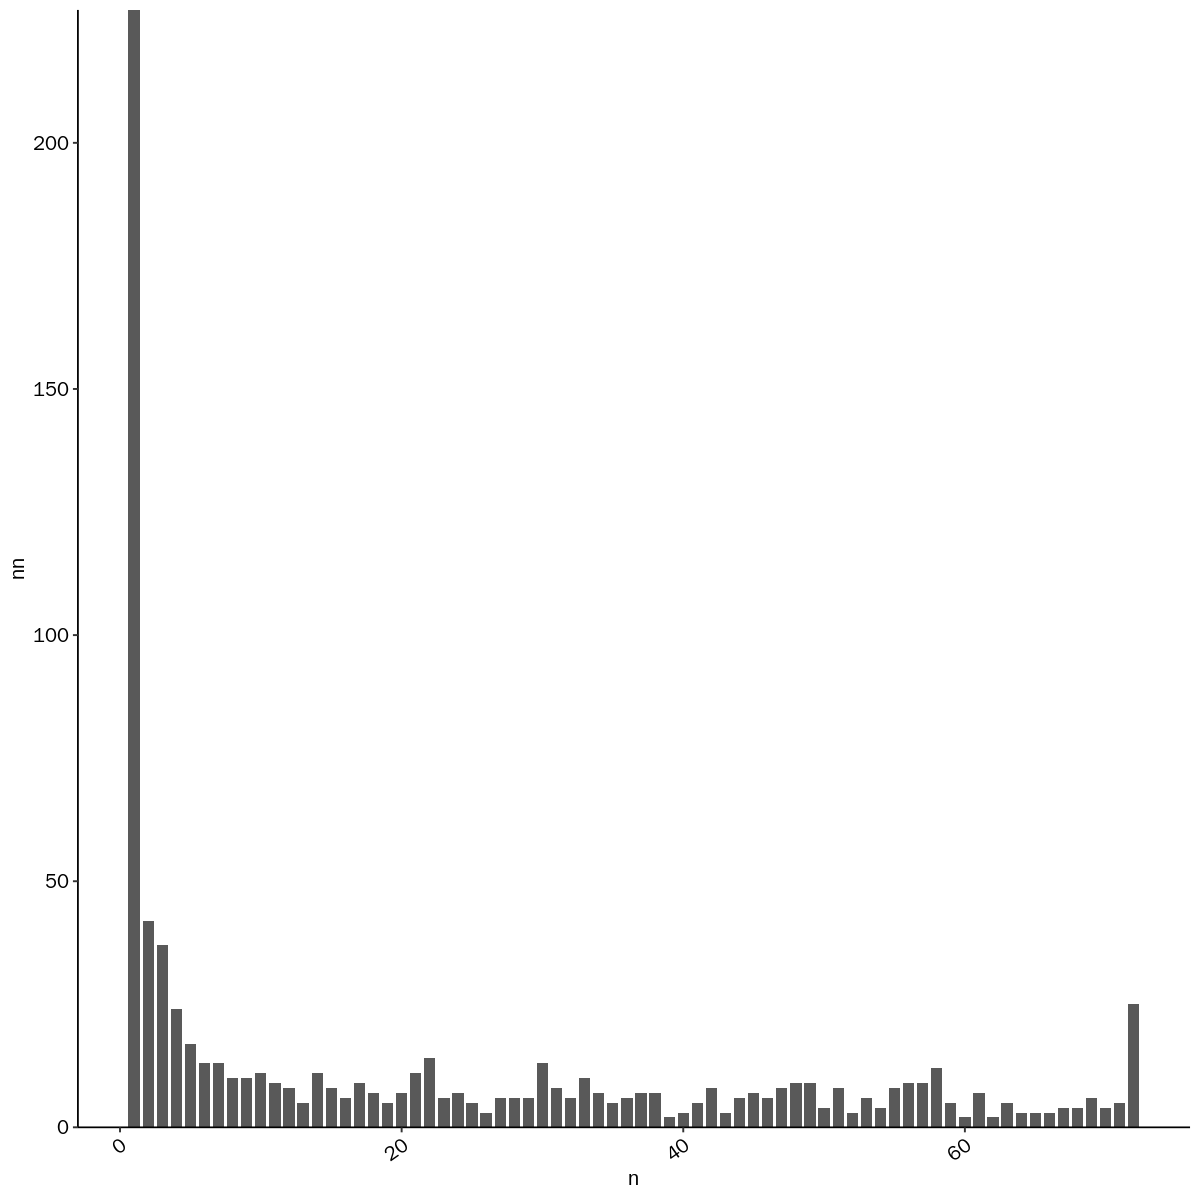

In [55]:
# 查看蛋白在一种富集方法一种酶切方法中重复被检测到的次数
count(df,Protein,Eyzyme,Enrichment) %>% 
group_by(Eyzyme,Enrichment) %>% 
count(n) -> df_1
library(ggplot2)
ggplot(df_1, aes(x=factor(n), y=nn, fill=Eyzyme)) +
geom_bar(stat='identity', position='dodge') +
facet_wrap(~Enrichment) +
labs(x='Number of technical replicates supporting protein detection', y='Frequency')+
theme_3()
# 79%的蛋白质测定被2个以上的技术重复支持
df_1 %>% group_by(n) %>% summarise(sum_nn=sum(nn)) -> df_all
df_all$sum_nn/sum(df_all$sum_nn) -> tmp
1-tmp[1]
df %>% count(Protein) %>% count(n) %>% bar_plot_stated("n","nn")
df %>% count(Protein) %>% count(n) -> df_2
df_2$nn/sum(df_2$nn) -> freq
# 72%的蛋白质被2次以上的测定所支持
1-freq[1]

In [47]:
all_sample_sep_m_meta %>% filter(grepl("^ENST",Protein))  -> df

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


[1] 0.6252523

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


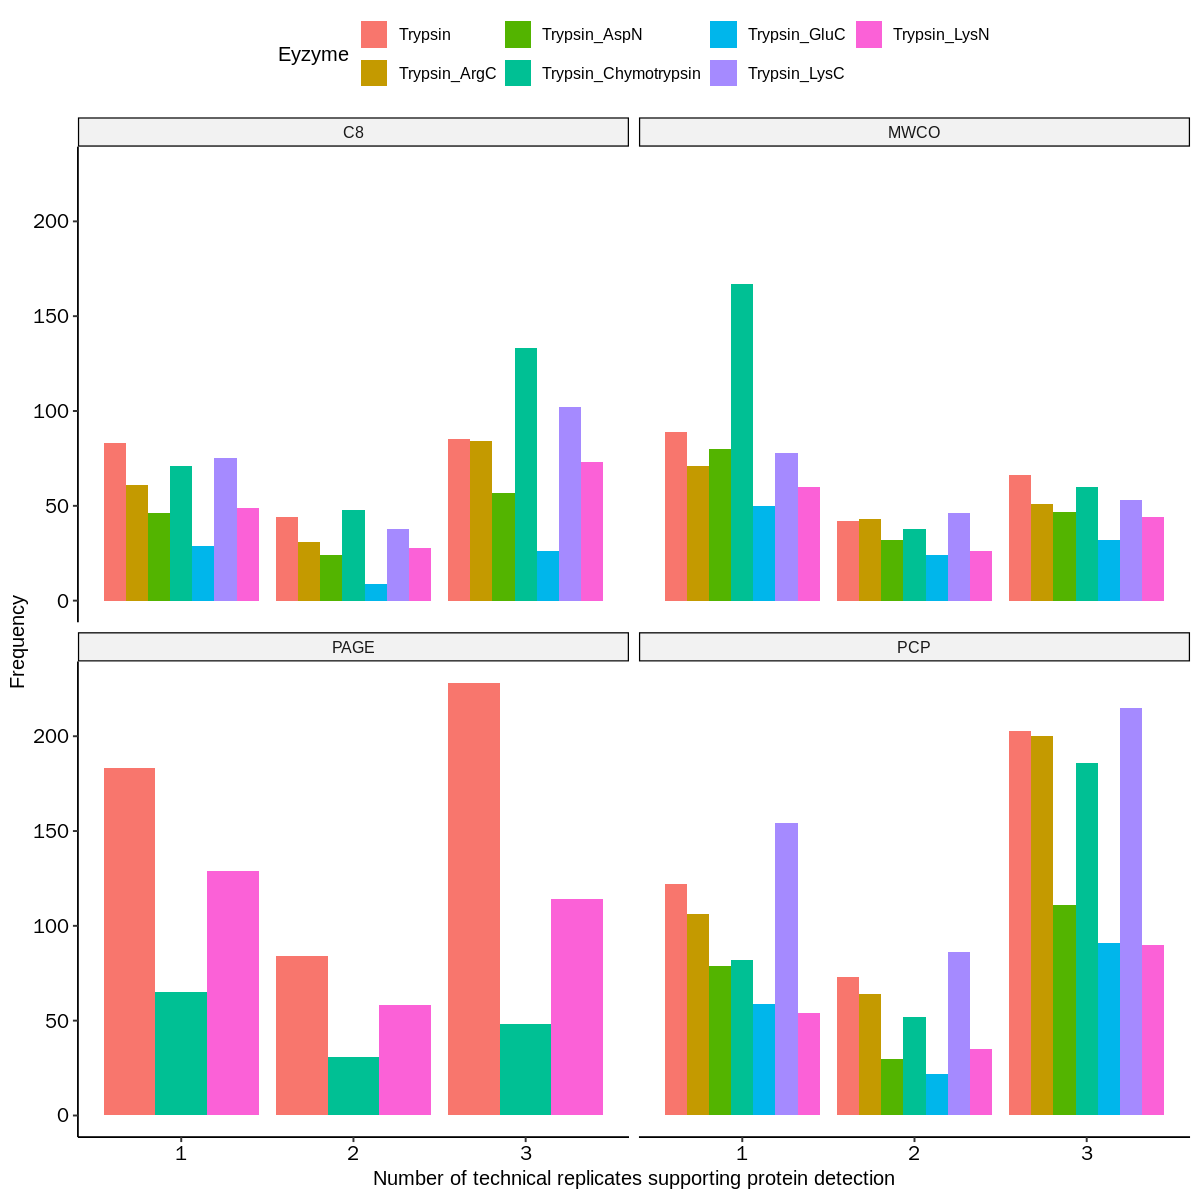

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


[1] 0.6606378

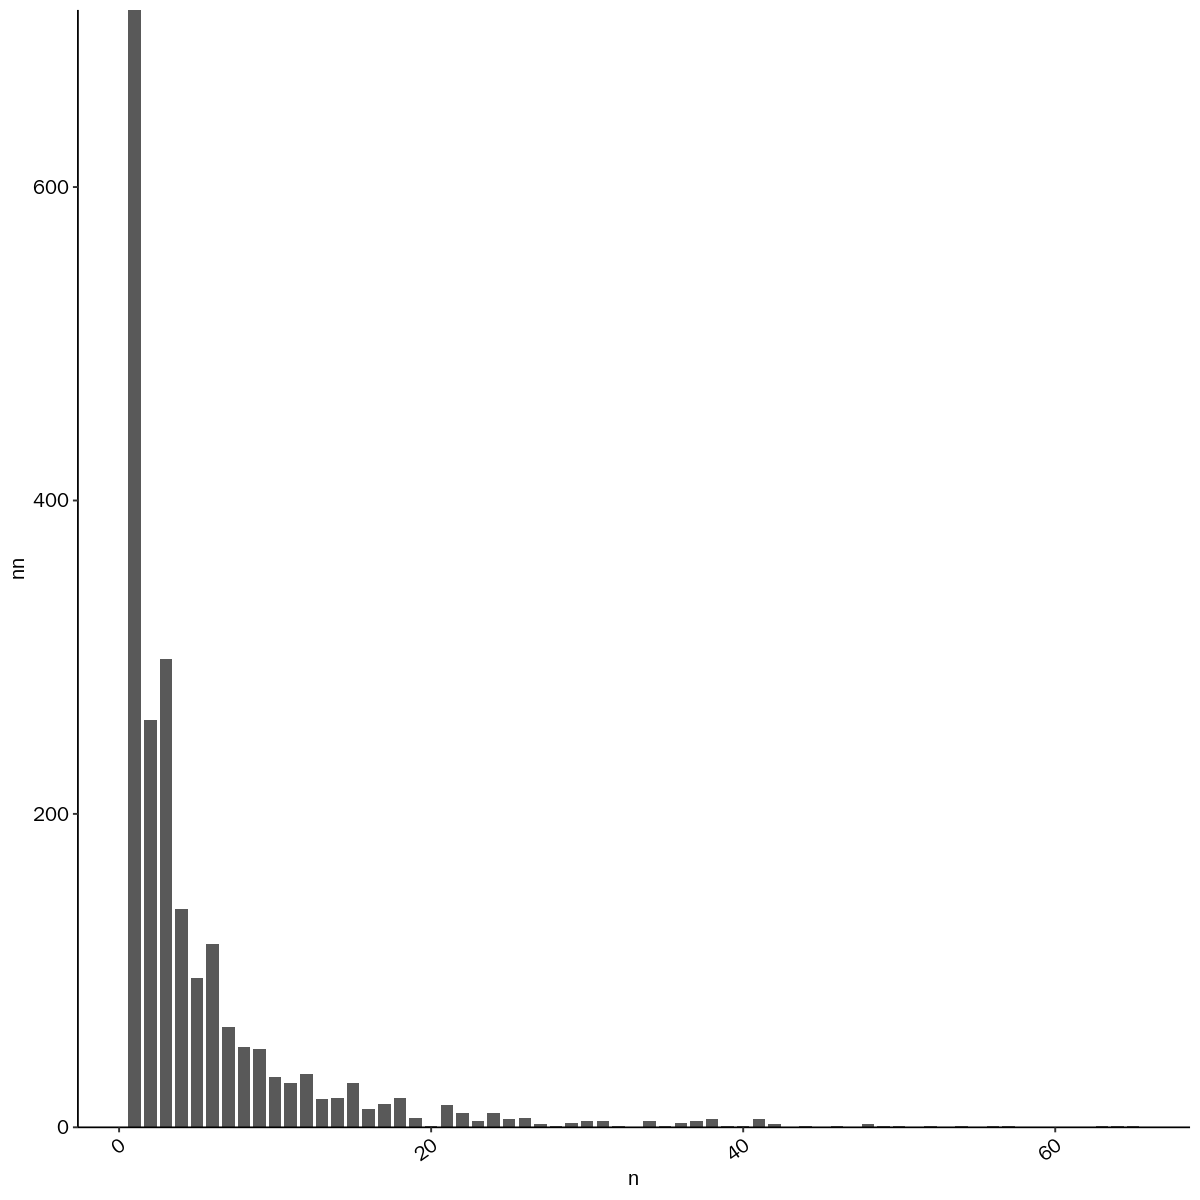

In [51]:
# 查看蛋白在一种富集方法一种酶切方法中重复被检测到的次数
count(df,Protein,Eyzyme,Enrichment) %>% 
group_by(Eyzyme,Enrichment) %>% 
count(n) -> df_1
library(ggplot2)
ggplot(df_1, aes(x=factor(n), y=nn, fill=Eyzyme)) +
geom_bar(stat='identity', position='dodge') +
facet_wrap(~Enrichment) +
labs(x='Number of technical replicates supporting protein detection', y='Frequency')+
theme_3()
# 63%的蛋白质测定被2个以上的技术重复支持
df_1 %>% group_by(n) %>% summarise(sum_nn=sum(nn)) -> df_all
df_all$sum_nn/sum(df_all$sum_nn) -> tmp
1-tmp[1]
df %>% count(Protein) %>% count(n) %>% bar_plot_stated("n","nn")
df %>% count(Protein) %>% count(n) -> df_2
df_2$nn/sum(df_2$nn) -> freq
# 66%的蛋白质被2次以上的测定所支持
1-freq[1]

# 热图

In [71]:
merge_replicate <- function(df){
    # 合并重复
    df$Sample_merge_replicate <- gsub("21pcw(_1|_2|_3)", "21pcw", df$Sample)
    distinct(df,Protein,Sample_merge_replicate,Eyzyme,Enrichment) -> df_1
    df_1 %>% rename(Sample=Sample_merge_replicate) -> df_2
    return(df_2)
}
define_type <- function(x){
    return(if_else(grepl("^sp",x),"Cano","Uncano"))
}

Warning message in brewer.pal(length(unique(protein_stats$Type)), "Set3"):
“minimal value for n is 3, returning requested palette with 3 different levels
”


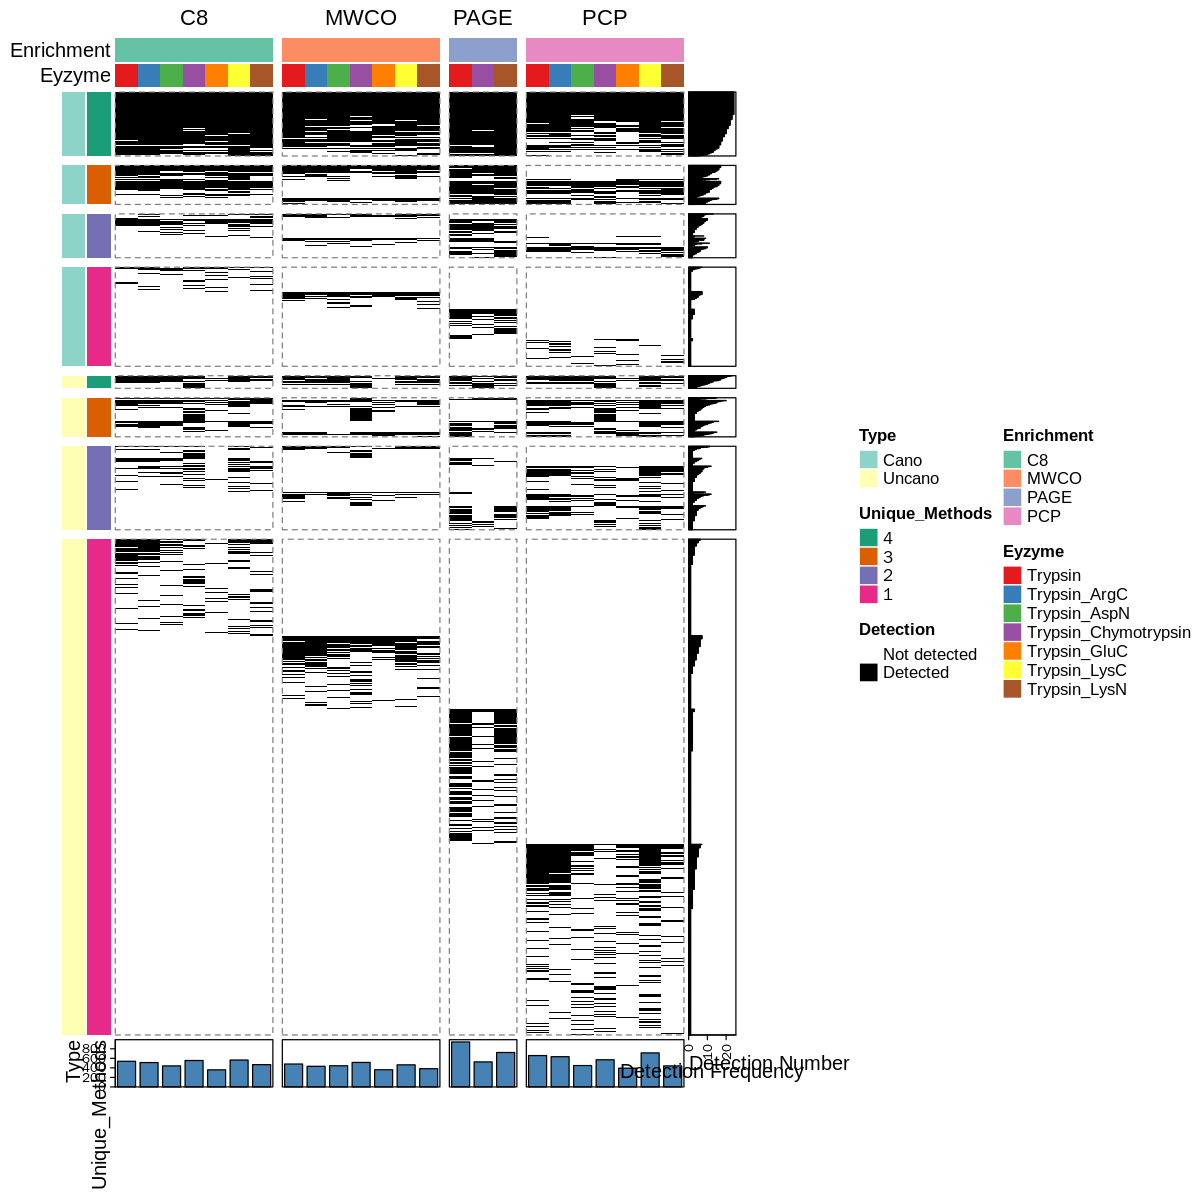

In [72]:
df <- merge_replicate(all_sample_sep_m_meta)
protein_stats <- df %>%
  group_by(Protein) %>%
  summarise(
    Unique_Methods = n_distinct(Enrichment),  # 被多少种不同富集方法鉴定到
    Total_Observations = n(),                 # 被鉴定到的总次数
    Supported_Enrichments = paste(sort(unique(Enrichment)), collapse = ", ")  # 支持的富集方法（去重后逗号分隔）
  )
protein_stats$Unique_Methods <- as.character(protein_stats$Unique_Methods)
protein_stats$Unique_Methods <- factor(protein_stats$Unique_Methods,levels=c('4','3','2','1'))
protein_stats$Type <- factor(define_type(protein_stats$Protein),levels = c("Cano","Uncano"))
protein_stats %>% arrange(Type,Unique_Methods, Supported_Enrichments,desc(Total_Observations)) -> protein_stats

library(ComplexHeatmap)
library(circlize)
# Create a binary detection matrix
binary_matrix_tmp <- df %>%
  mutate(present = 1) %>%
  select(Sample, Protein, present) %>%
  pivot_wider(names_from = Sample, values_from = present, values_fill = 0) %>%
  column_to_rownames("Protein") %>%
  as.matrix()
# 按照特定顺序排序
binary_matrix_tmp[protein_stats$Protein,] -> binary_matrix
# Calculate detection frequency for each protein
detection_freq <- rowSums(binary_matrix)
detection_number <- colSums(binary_matrix)

# Get unique sample annotations
sample_annot <- df %>%
  select(Sample,Enrichment,Eyzyme) %>%
  distinct() %>%
  column_to_rownames("Sample")

# Define colors for annotations
enzyme_colors <- setNames(brewer.pal(length(unique(sample_annot$Eyzyme)), "Set1"), 
                          unique(sample_annot$Eyzyme))
enrichment_colors <- setNames(brewer.pal(length(unique(sample_annot$Enrichment)), "Set2"), 
                              unique(sample_annot$Enrichment))
# Create column annotations
col_ha <- HeatmapAnnotation(
  df = sample_annot,
  col = list(
    Eyzyme = enzyme_colors,
    Enrichment = enrichment_colors
  ),
  annotation_name_side = "left"
)

# Create row annotation for detection frequency
row_ha <- rowAnnotation(
  "Detection Frequency" = anno_barplot(detection_freq, 
                                       bar_width = 0.8,
                                       gp = gpar(fill = "steelblue",col=NULL))
)
col_ha_1 <- columnAnnotation(
  "Detection Number" = anno_barplot(detection_number, 
                                       bar_width = 0.8,
                                       gp = gpar(fill = "steelblue",col=NULL))
)

# Define colors for annotations
type_colors <- setNames(brewer.pal(length(unique(protein_stats$Type)), "Set3"), 
                          unique(protein_stats$Type))
method_colors <- setNames(brewer.pal(length(unique(protein_stats$Unique_Methods)), "Dark2"), 
                              unique(protein_stats$Unique_Methods))
protein_stats[,c("Type","Unique_Methods")]  %>% as.data.frame() -> row_anno
rownames(row_anno) <- protein_stats$Protein
# Create column annotations
row_ha_1 <- rowAnnotation(
  df = row_anno,
  col = list(
    Type = type_colors[1:2],
    Unique_Methods = method_colors
  ),
  annotation_name_side = "bottom"
)

column_split <- factor(
  sample_annot$Enrichment, 
  levels = unique(sample_annot$Enrichment) 
)
groups <- paste0(protein_stats$Type,"-",protein_stats$Unique_Methods)
row_split <- factor(
    groups, 
    levels = unique(groups)
)

options(repr.plot.width = 10, repr.plot.height = 10)
ht <- Heatmap(
    binary_matrix,
    name = "Detection",
    col = c("white", "black"),
    cluster_columns = FALSE,
    cluster_rows = FALSE,
    row_title=NULL,
    show_row_names = FALSE,
    show_column_names = FALSE,
    top_annotation = col_ha,
    right_annotation = row_ha,
    left_annotation = row_ha_1,
    bottom_annotation = col_ha_1,
    column_split = column_split,
    row_split = row_split,
    heatmap_legend_param = list(
        at = c(0, 1),
        labels = c("Not detected", "Detected")
    ),
    use_raster = FALSE,
    # 添加虚线分隔
    row_gap = unit(2, "mm"),
    column_gap = unit(2, "mm"),
    border_gp = gpar(lty = "dashed", col = "grey50")  # 替代方法
)
ht

In [ ]:
# Draw the heatmap
# 1. 打开 PDF 设备，设置文件名和尺寸（单位：英寸）
pdf(o("protein_detection_heatmap.pdf"), width = 12, height = 8)
# 2. 绘制热图（假设 `ht` 是你的 Heatmap 对象）
draw(ht)
# 3. 关闭设备，保存文件
dev.off()

## 列使用binary方法进行距离测算

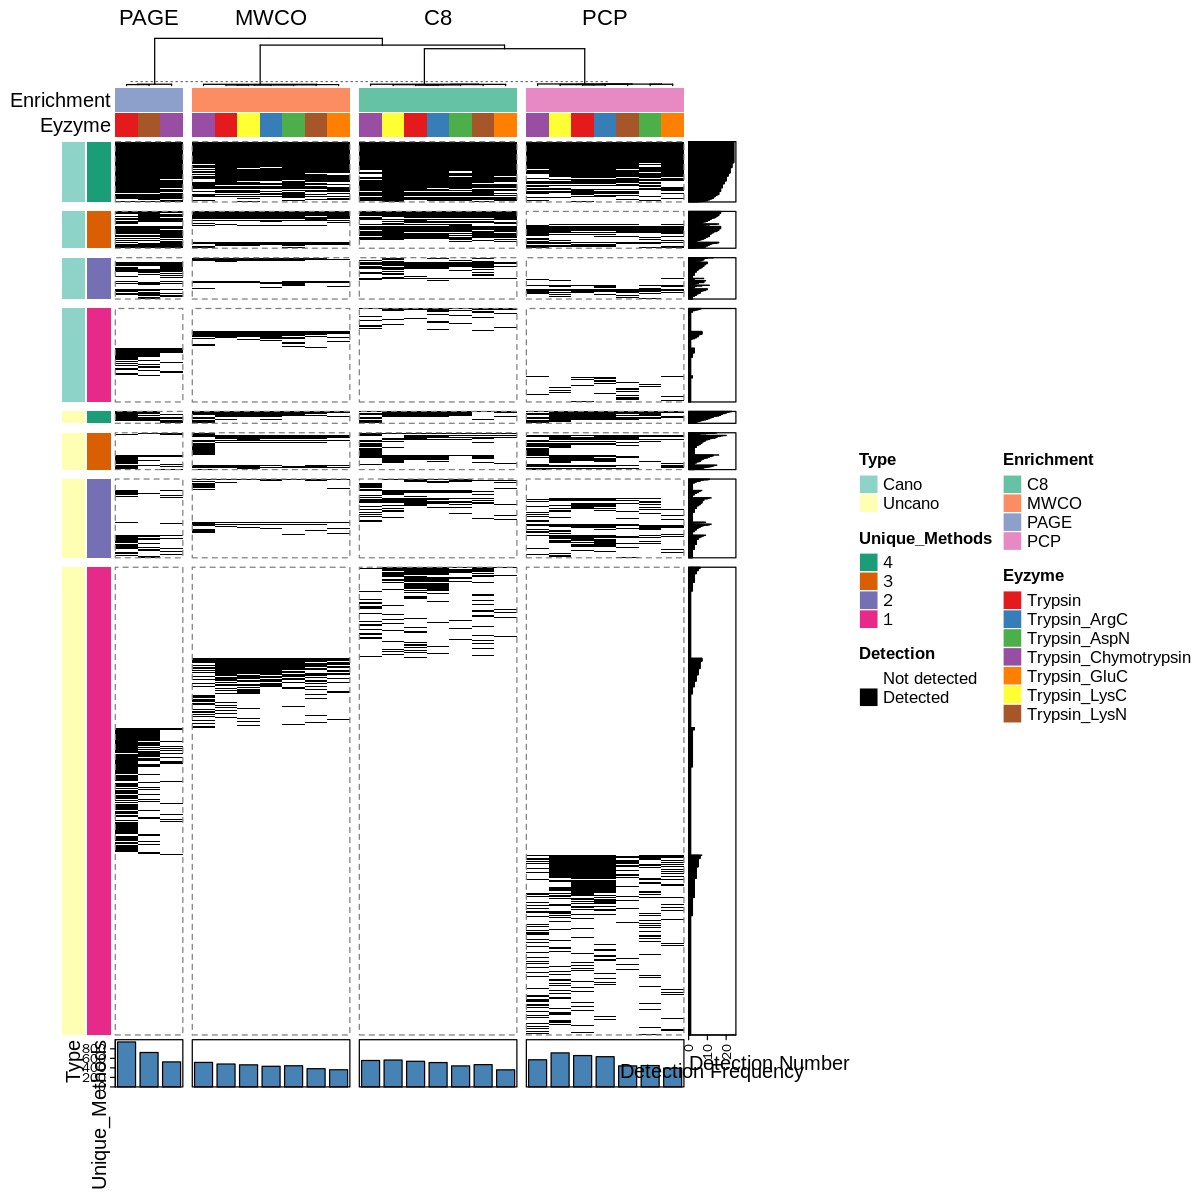

In [90]:
Heatmap(
    binary_matrix,
    name = "Detection",
    col = c("white", "black"),
    cluster_columns = TRUE,
    cluster_rows = FALSE,
    clustering_distance_columns="binary",
    row_title=NULL,
    show_row_names = FALSE,
    show_column_names = FALSE,
    top_annotation = col_ha,
    right_annotation = row_ha,
    left_annotation = row_ha_1,
    bottom_annotation = col_ha_1,
    column_split = column_split,
    row_split = row_split,
    heatmap_legend_param = list(
        at = c(0, 1),
        labels = c("Not detected", "Detected")
    ),
    use_raster = FALSE,
    # 添加虚线分隔
    row_gap = unit(2, "mm"),
    column_gap = unit(2, "mm"),
    border_gp = gpar(lty = "dashed", col = "grey50")  # 替代方法
)

In [92]:
head(protein_stats)

Protein,Unique_Methods,Total_Observations,Supported_Enrichments,Type
<chr>,<fct>,<int>,<chr>,<fct>
sp|C9JLW8|MCRI1_HUMAN,4,24,"C8, MWCO, PAGE, PCP",Cano
sp|O00244|ATOX1_HUMAN,4,24,"C8, MWCO, PAGE, PCP",Cano
sp|O43169|CYB5B_HUMAN,4,24,"C8, MWCO, PAGE, PCP",Cano
sp|O75368|SH3L1_HUMAN,4,24,"C8, MWCO, PAGE, PCP",Cano
sp|O75380|NDUS6_HUMAN,4,24,"C8, MWCO, PAGE, PCP",Cano
sp|O75531|BAF_HUMAN,4,24,"C8, MWCO, PAGE, PCP",Cano
